In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
heart_disease=pd.read_csv(r"C:\Users\HP\Downloads\heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
heart_disease.shape  #check dataset shape

(303, 14)

In [5]:
heart_disease.dtypes  #check features datatypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [6]:
heart_disease.isna().sum() #checking if we have missing values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [ ]:
heart_disease["target"].value_counts() #class balance: how many 0s vs 1s we have?

target
1    165
0    138
Name: count, dtype: int64

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X=heart_disease.drop("target",axis=1)
y=heart_disease["target"]

#even on a clean data, pipeline is the professional default
# (if a future patient's data has a blank cell, this simple imputer handles it)
# the model gets filled in the next section 

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [21]:
from sklearn.linear_model import LogisticRegression

model=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
        ("model",LogisticRegression(max_iter=1000))])# maximize iterations so it converges

model.fit(X_train,y_train)
model.score(X_test,y_test)# for a classifier score=accuracy

0.8688524590163934

In [22]:
#hard decisions
model.predict(X_test[:5])

array([1, 0, 1, 1, 0])

In [23]:
#confidence behind those decisions 2 columns: P(class 0),P(class 1)
model.predict_proba(X_test[:5])

array([[0.24867021, 0.75132979],
       [0.9539185 , 0.0460815 ],
       [0.4427488 , 0.5572512 ],
       [0.03391336, 0.96608664],
       [0.9698041 , 0.0301959 ]])

In [24]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
y_preds=model.predict(X_test)
confusion_matrix(y_test,y_preds)

array([[20,  8],
       [ 0, 33]])

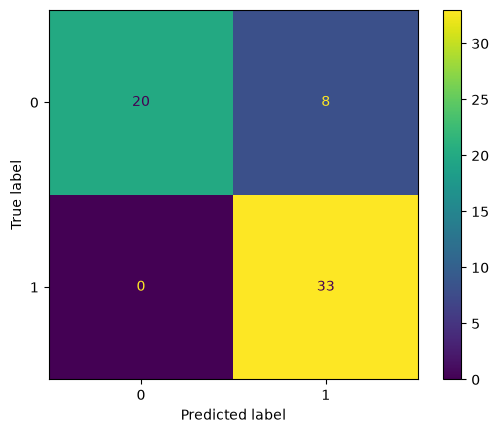

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test,y_preds)

In [26]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_preds))

0.8688524590163934


In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       1.00      0.71      0.83        28
           1       0.80      1.00      0.89        33

    accuracy                           0.87        61
   macro avg       0.90      0.86      0.86        61
weighted avg       0.89      0.87      0.87        61



AUC score : 0.9545454545454546


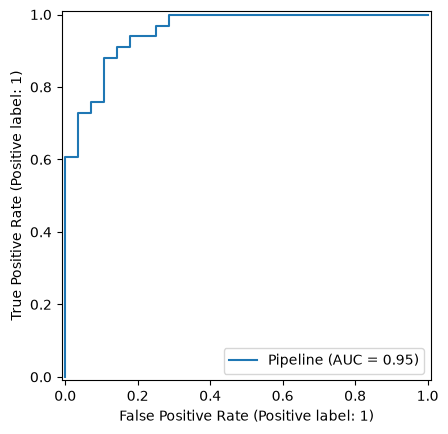

In [29]:
from sklearn.metrics import RocCurveDisplay,roc_auc_score
#probabilities of the positive class
y_probs=model.predict_proba(X_test)[:,1]

print(f"AUC score : {roc_auc_score(y_test,y_probs)}")

RocCurveDisplay.from_estimator(model,X_test,y_test)


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
        ("model",RandomForestClassifier())])

rf_model.fit(X_train,y_train)
print(f"Logistic Regression score: {model.score(X_test,y_test)}")
print(f"Random Forest score: {rf_model.score(X_test,y_test)}")


Logistic Regression score: 0.8688524590163934
Random Forest score: 0.8360655737704918


In [33]:
from sklearn.model_selection import GridSearchCV

param_grid={
    "model__n_estimators":[100,200,500],
    "model__max_depth":[None,5,10],
    "model__min_samples_split":[2,4,6]}

#scoring="recall" - tune toward catching sick patients, not raw accuracy

gs=GridSearchCV(rf_model,param_grid,cv=5,scoring="recall",verbose=2)
gs.fit(X_train,y_train)
print(gs.best_params_)
print(f"Best CV recall : {gs.best_score_}")


Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.1s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   0.2s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   0.2s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   0.2s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   0.2s
[C

In [35]:
import pickle

from joblib import load,dump

best_model=gs.best_estimator_

# pickle
pickle.dump(best_model,open("heart_disease_model.pkl","wb"))
loaded=pickle.load(open("heart_disease_model.pkl","rb"))
print(f"Loaded pickle accuracy : {loaded.score(X_test,y_test)}")

#jobllib
dump(best_model,"heart_disease_model.joblib")
loaded_joblib=load("heart_disease_model.joblib")
print(f"Loaded joblib accuracy : {loaded_joblib.score(X_test,y_test)}")


Loaded pickle accuracy : 0.8360655737704918
Loaded joblib accuracy : 0.8360655737704918
